# **Project Name** - Anomaly Detection in Financial Transactions

##### **Project Type** - Classification and anomaly detection
##### **Contribution** - Individual
##### **Team Member 1** - Bijitesh Kanrar

**Advanced Machine Learning | Banking and Finance**

# **Project Summary -**

Financial institutions must identify rare fraudulent card transactions among a very large number of legitimate payments. A useful system should catch fraud without overwhelming investigators or inconveniencing customers with false alerts. This project develops an auditable fraud-screening workflow using the ULB/Worldline credit-card benchmark. Its 284,807 transactions span about two days and include 492 labelled frauds, roughly 0.17% of the data. The variables `V1`–`V28` are anonymized principal-component features; `Time`, `Amount`, and the binary target `Class` complete the source schema. The notebook reads the bundled dataset from the project repository and saves outputs to Google Drive when run in Colab.

The analysis validates the schema, records missing and duplicate values, removes unusable records, and engineers log amount and cyclic time-of-day features. Unusual values are retained because they may be the very events the models must find. Data are ordered by time and divided into 70% training, 15% validation, and 15% test. Preprocessing is fitted on training data only. The novelty detectors learn from normal training transactions, while a supervised Random Forest uses both classes. Exploratory charts and hypothesis tests use the training partition so that later labels do not guide modelling decisions.

Five approaches are compared: a transparent interquartile-range amount baseline, Isolation Forest, Local Outlier Factor in novelty mode, PCA reconstruction error, and a supervised Random Forest benchmark. PCA does not feed a separate classifier: reconstruction error itself becomes the anomaly score. The Random Forest uses class weighting and, when `imbalanced-learn` is available, training-only SMOTE. The current SMOTE setting is `k_neighbors=3`, changed from 5 after a controlled local comparison. Anomaly-family hyperparameters are chosen on validation data with a compact grid; the Random Forest parameters are fixed rather than searched.

Every model receives a validation-selected alert threshold. The illustrative relative cost is 25 for a missed fraud and 1 for a false alert. The notebook reports precision, recall, F1, F2, PR-AUC, ROC-AUC, false-positive rate, confusion counts, and precision among the top 100 alerts. Test data are evaluated only after choices are locked. Accuracy alone is unhelpful here: predicting every case as legitimate would look impressive while catching no fraud.

The best *anomaly detector* and best *overall model* are distinct questions. The anomaly-only selection deliberately excludes the supervised Random Forest. A previous Colab validation display favored PCA within the anomaly set, while Random Forest had a higher overall F2; the executed tables in this notebook must determine the result for the submitted run. Lack of labels on an incoming transaction does not prevent an already trained Random Forest from predicting, but labels are needed to train it and to measure performance.

The notebook saves a selected deployable anomaly detector, its scaler, feature order, and threshold, then reloads the bundle for a scoring check. This is a notebook inference demonstration rather than a live banking service. Any operational use would need feed validation, authentication, monitoring, human review, delayed-label evaluation, and rollback controls. The benchmark's two-day window, anonymized features, and missing customer, merchant, device, and geographic context limit business explanation and generalization. The final recommendation must follow the real-data run and operational review capacity, not a preselected algorithm or synthetic smoke-test output.

# **GitHub Link -**

[Project repository and runnable Colab notebook](https://github.com/CA-BijiteshKanrar/ADFT-BK)

# **Problem Statement**

Rank transactions by fraud risk and choose a review threshold that captures fraud while controlling false alerts and investigation workload. The flag is a **manual-review recommendation**, not proof of fraud or authorization to block a payment. The business objective balances fraud loss avoided, review cost, customer friction, latency, and maintainability. Here, a missed fraud is assigned 25 times the relative cost of a false alert for illustration; a bank would replace this assumption with measured costs.

**Research questions:** Which novelty detector performs best at a practical alert volume? How much do training labels improve the result? What threshold follows from the stated cost ratio?

# ***Let's Begin !***

Run the cells from top to bottom in a fresh Google Colab runtime. The dataset is included in the linked repository. Real-data findings require `source_info["is_synthetic"] == False`; synthetic data are only a pipeline smoke test. All generated figures and tables are written under the Google Drive project folder.

## ***1. Know Your Data***

### Import Libraries and initialize the Colab project

In [2]:
# Run this setup cell in a fresh Google Colab runtime.
import subprocess
import sys
from pathlib import Path
from google.colab import drive

REPO_URL = "https://github.com/CA-BijiteshKanrar/ADFT-BK.git"
REPO_DIR = Path("/content/ADFT-BK")
DATA_ARCHIVE = REPO_DIR / "content" / "creditcard.csv.zip"
# Reuse the project clone when present; refresh only an older clone missing the data ZIP.
if REPO_DIR.exists():
    if not (REPO_DIR / ".git").is_dir():
        raise RuntimeError(f"{REPO_DIR} exists but is not a Git clone.")
    if not DATA_ARCHIVE.is_file():
        # Refresh an older clone made before the dataset was added.
        subprocess.run(
            ["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", "main"],
            check=True,
        )
    print(f"Reusing GitHub clone: {REPO_DIR}")
else:
    subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", "main", REPO_URL, str(REPO_DIR)],
        check=True,
    )
    print(f"Cloned GitHub project to: {REPO_DIR}")

# Analysis functions are embedded below; the bundled dataset is read from the clone.
# Install the notebook dependencies in the active Colab runtime.
subprocess.run(
    [
        sys.executable, "-m", "pip", "install", "-q",
        "numpy>=1.26,<3", "pandas>=2.1,<3", "scikit-learn>=1.4,<2",
        "imbalanced-learn>=0.12,<1", "matplotlib>=3.8,<4",
        "seaborn>=0.13,<1", "joblib>=1.3,<2",
    ],
    check=True,
)

# Keep reports, figures, and the fitted bundle beyond the temporary runtime.
drive.mount("/content/drive")
PROJECT_DIR = Path("/content/drive/MyDrive/Financial_Transaction_Anomaly_Detection")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Drive project folder: {PROJECT_DIR}")

Reusing GitHub clone: /content/ADFT-BK
Mounted at /content/drive
Drive project folder: /content/drive/MyDrive/Financial_Transaction_Anomaly_Detection


The analysis functions below are embedded in this notebook so the repository clone supplies the dataset rather than Python modules. The setup cell installs the required packages, clones or reuses the repository, and mounts Google Drive for persistent outputs.

In [3]:
"""Core utilities for the financial transaction anomaly-detection project.

These functions are embedded so the notebook can run independently in Colab.
"""

from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

import joblib
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, make_classification
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler


V_FEATURES = [f"V{i}" for i in range(1, 29)]
RAW_FEATURES = ["Time", *V_FEATURES, "Amount"]
REQUIRED_COLUMNS = [*RAW_FEATURES, "Class"]
MODEL_FEATURES = [*V_FEATURES, "LogAmount", "HourSin", "HourCos"]


@dataclass
class SplitData:
    train: pd.DataFrame
    validation: pd.DataFrame
    test: pd.DataFrame
    strategy: str


class PCAReconstructionDetector:
    """PCA detector whose anomaly score is scaled reconstruction error."""

    def __init__(self, n_components: float | int = 0.95, random_state: int = 42):
        self.n_components = n_components
        self.random_state = random_state
        self.pca_: PCA | None = None

    def fit(self, X: np.ndarray) -> "PCAReconstructionDetector":
        self.pca_ = PCA(
            n_components=self.n_components,
            svd_solver="full",
            random_state=self.random_state,
        )
        self.pca_.fit(X)
        return self

    def score_samples(self, X: np.ndarray) -> np.ndarray:
        if self.pca_ is None:
            raise RuntimeError("The detector must be fitted before scoring.")
        # Reconstruction error is the anomaly score; no classifier follows PCA.
        reconstructed = self.pca_.inverse_transform(self.pca_.transform(X))
        return np.mean(np.square(X - reconstructed), axis=1)


def validate_schema(df: pd.DataFrame, require_target: bool = True) -> None:
    # Require the target for labelled data, but allow target-free inference rows.
    required = REQUIRED_COLUMNS if require_target else RAW_FEATURES
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    if require_target:
        labels = set(pd.to_numeric(df["Class"], errors="coerce").dropna().unique())
        if not labels.issubset({0, 1}):
            raise ValueError("Class must contain only binary labels 0 and 1.")


def generate_synthetic_transactions(
    n_samples: int = 30_000,
    fraud_ratio: float = 0.006,
    random_state: int = 42,
) -> pd.DataFrame:
    """Generate a schema-compatible dataset for development smoke tests only."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=28,
        n_informative=12,
        n_redundant=8,
        n_repeated=0,
        n_clusters_per_class=3,
        weights=[1.0 - fraud_ratio, fraud_ratio],
        class_sep=1.45,
        flip_y=0.0005,
        random_state=random_state,
    )
    rng = np.random.default_rng(random_state)
    frame = pd.DataFrame(X, columns=V_FEATURES)
    frame["Time"] = np.sort(rng.uniform(0, 172_800, size=n_samples))
    normal_amount = rng.lognormal(mean=3.1, sigma=1.0, size=n_samples)
    fraud_multiplier = np.where(y == 1, rng.uniform(1.1, 3.0, n_samples), 1.0)
    frame["Amount"] = np.round(normal_amount * fraud_multiplier, 2)
    frame["Class"] = y.astype(int)
    return frame[["Time", *V_FEATURES, "Amount", "Class"]]


def load_transactions(
    csv_path: str | Path = "/content/creditcard.csv",
    *,
    fallback_paths: Iterable[str | Path] = (),
    allow_openml: bool = True,
    allow_synthetic: bool = False,
    synthetic_rows: int = 30_000,
    random_state: int = 42,
) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Load the bundled ZIP or fallback CSV, then OpenML or synthetic smoke data."""
    # Prefer the bundled real dataset before trying external or synthetic fallbacks.
    candidates = [Path(csv_path), *(Path(path) for path in fallback_paths)]
    for candidate in candidates:
        if candidate.is_file():
            df = pd.read_csv(candidate, compression="infer")
            validate_schema(df)
            return df, {
                "source": str(candidate.resolve()),
                "is_synthetic": False,
                "note": "Loaded from bundled ZIP." if candidate.suffix == ".zip" else "Loaded from CSV.",
            }

    openml_error: str | None = None
    if allow_openml:
        try:
            bunch = fetch_openml(data_id=1597, as_frame=True, parser="auto")
            df = bunch.frame.copy()
            if "Class" not in df.columns and bunch.target is not None:
                df["Class"] = bunch.target
            df["Class"] = pd.to_numeric(df["Class"], errors="raise").astype(int)
            validate_schema(df)
            return df, {
                "source": "OpenML dataset 1597 (creditcard)",
                "is_synthetic": False,
                "note": "Downloaded through sklearn.fetch_openml.",
            }
        except Exception as exc:  # network/auth varies by execution platform
            openml_error = f"{exc.__class__.__name__}: {exc}"

    if allow_synthetic:
        df = generate_synthetic_transactions(
            n_samples=synthetic_rows,
            random_state=random_state,
        )
        return df, {
            "source": "Synthetic development data",
            "is_synthetic": True,
            "note": (
                "SMOKE TEST ONLY. Replace with the ULB creditcard.csv before "
                "submitting results."
            ),
            "openml_error": openml_error,
        }

    raise FileNotFoundError(
        "The bundled dataset ZIP and fallback CSV files were not found, and "
        "OpenML could not be loaded. OpenML error: "
        f"{openml_error or 'not attempted'}"
    )


def clean_transactions(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, Any]]:
    """Coerce types, remove exact duplicates, and document data-quality actions."""
    validate_schema(df)
    clean = df[REQUIRED_COLUMNS].copy()
    for column in REQUIRED_COLUMNS:
        clean[column] = pd.to_numeric(clean[column], errors="coerce")
    missing_before = clean.isna().sum().to_dict()
    rows_before = len(clean)
    # Remove unusable records and exact duplicates, not merely extreme transactions.
    clean = clean.dropna().drop_duplicates().reset_index(drop=True)
    clean["Class"] = clean["Class"].astype(int)
    clean["Amount"] = clean["Amount"].clip(lower=0)
    validate_schema(clean)
    audit = {
        "rows_before": rows_before,
        "rows_after": len(clean),
        "rows_removed": rows_before - len(clean),
        "missing_before": {k: int(v) for k, v in missing_before.items()},
    }
    return clean, audit


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create robust amount and cyclical time features without using the label."""
    validate_schema(df, require_target=False)
    out = df.copy()
    # Map elapsed time to a circular 24-hour clock before sine/cosine encoding.
    seconds_in_day = np.mod(out["Time"].to_numpy(dtype=float), 86_400.0)
    hour = seconds_in_day / 3_600.0
    out["LogAmount"] = np.log1p(out["Amount"].clip(lower=0))
    out["HourSin"] = np.sin(2 * np.pi * hour / 24.0)
    out["HourCos"] = np.cos(2 * np.pi * hour / 24.0)
    return out


def chronological_split(
    df: pd.DataFrame,
    train_fraction: float = 0.70,
    validation_fraction: float = 0.15,
    random_state: int = 42,
) -> SplitData:
    """Use deployment-like time splits, with a documented stratified fallback."""
    from sklearn.model_selection import train_test_split

    # Earlier transactions train the model; later transactions validate and test it.
    ordered = df.sort_values("Time").reset_index(drop=True)
    train_end = int(len(ordered) * train_fraction)
    validation_end = int(len(ordered) * (train_fraction + validation_fraction))
    train = ordered.iloc[:train_end].copy()
    validation = ordered.iloc[train_end:validation_end].copy()
    test = ordered.iloc[validation_end:].copy()
    if all(part["Class"].nunique() == 2 for part in (train, validation, test)):
        return SplitData(train, validation, test, "chronological 70/15/15")

    # Small development samples may need a stratified fallback to retain both classes.
    train, remainder = train_test_split(
        ordered,
        test_size=1 - train_fraction,
        stratify=ordered["Class"],
        random_state=random_state,
    )
    relative_test = (1 - train_fraction - validation_fraction) / (1 - train_fraction)
    validation, test = train_test_split(
        remainder,
        test_size=relative_test,
        stratify=remainder["Class"],
        random_state=random_state,
    )
    return SplitData(
        train.sort_values("Time").copy(),
        validation.sort_values("Time").copy(),
        test.sort_values("Time").copy(),
        "stratified fallback because a chronological partition lacked a class",
    )


def cap_rows(
    X: np.ndarray,
    max_rows: int,
    random_state: int = 42,
) -> np.ndarray:
    if len(X) <= max_rows:
        return X
    rng = np.random.default_rng(random_state)
    return X[rng.choice(len(X), size=max_rows, replace=False)]


def fit_anomaly_models(
    X_train_normal_scaled: np.ndarray,
    *,
    fast_mode: bool = False,
    random_state: int = 42,
) -> dict[str, Any]:
    """Fit complementary global, local, and reconstruction-based detectors."""
    iso_rows = 25_000 if fast_mode else 100_000
    lof_rows = 10_000 if fast_mode else 45_000
    normal_iso = cap_rows(X_train_normal_scaled, iso_rows, random_state)
    normal_lof = cap_rows(X_train_normal_scaled, lof_rows, random_state)

    models: dict[str, Any] = {
        "Isolation Forest": IsolationForest(
            n_estimators=200 if fast_mode else 350,
            max_samples="auto",
            contamination="auto",
            random_state=random_state,
            n_jobs=-1,
        ).fit(normal_iso),
        "Local Outlier Factor": LocalOutlierFactor(
            n_neighbors=35,
            novelty=True,
            contamination="auto",
            n_jobs=-1,
        ).fit(normal_lof),
        "PCA Reconstruction": PCAReconstructionDetector(
            n_components=0.95,
            random_state=random_state,
        ).fit(normal_iso),
    }
    return models


def tune_anomaly_models(
    X_train_normal_scaled: np.ndarray,
    X_validation_scaled: np.ndarray,
    y_validation: np.ndarray,
    *,
    false_negative_cost: float = 25.0,
    false_positive_cost: float = 1.0,
    fast_mode: bool = False,
    random_state: int = 42,
) -> tuple[dict[str, Any], pd.DataFrame]:
    """Tune compact, explainable grids on validation cost within each family."""
    iso_rows = 25_000 if fast_mode else 100_000
    # Fit novelty detectors only on normal training rows; cap rows for tractable tuning.
    lof_rows = 10_000 if fast_mode else 35_000
    normal_iso = cap_rows(X_train_normal_scaled, iso_rows, random_state)
    normal_lof = cap_rows(X_train_normal_scaled, lof_rows, random_state)

    iso_grid = (
        [(120, "auto")]
        if fast_mode
        else [(200, "auto"), (350, "auto"), (350, 0.50), (350, 0.80)]
    )
    lof_grid = [20] if fast_mode else [20, 35, 50]
    pca_grid = [0.95] if fast_mode else [0.90, 0.95, 0.99]

    # Search a small grid within each anomaly-model family.
    candidates: list[tuple[str, dict[str, Any], Any, np.ndarray]] = []
    for n_estimators, max_samples in iso_grid:
        params = {"n_estimators": n_estimators, "max_samples": max_samples}
        model = IsolationForest(
            n_estimators=n_estimators,
            max_samples=max_samples,
            contamination="auto",
            random_state=random_state,
            n_jobs=-1,
        ).fit(normal_iso)
        candidates.append(("Isolation Forest", params, model, X_validation_scaled))

    for n_neighbors in lof_grid:
        params = {"n_neighbors": n_neighbors}
        model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            novelty=True,
            contamination="auto",
            n_jobs=-1,
        ).fit(normal_lof)
        candidates.append(("Local Outlier Factor", params, model, X_validation_scaled))

    for n_components in pca_grid:
        params = {"variance_retained": n_components}
        model = PCAReconstructionDetector(
            n_components=n_components,
            random_state=random_state,
        ).fit(normal_iso)
        candidates.append(("PCA Reconstruction", params, model, X_validation_scaled))

    rows: list[dict[str, Any]] = []
    fitted: list[tuple[str, Any]] = []
    # Score later validation rows and choose a threshold without inspecting test labels.
    for family, params, model, X_val in candidates:
        scores = anomaly_score(family, model, X_val)
        choice = select_cost_threshold(
            y_validation,
            scores,
            false_negative_cost=false_negative_cost,
            false_positive_cost=false_positive_cost,
        )
        metrics = classification_metrics(y_validation, scores, choice["threshold"])
        rows.append(
            {
                "Family": family,
                "Parameters": json.dumps(params, sort_keys=True),
                "Validation_Cost": choice["validation_cost"],
                "F2": metrics["F2"],
                "PR_AUC": metrics["PR_AUC"],
                "Recall": metrics["Recall"],
                "Precision": metrics["Precision"],
                "Threshold": choice["threshold"],
            }
        )
        fitted.append((family, model))

    tuning_table = pd.DataFrame(rows)
    tuning_table["Selected"] = False
    selected: dict[str, Any] = {}
    # Choose one setting per family by cost, then F2 and PR-AUC as tie-breakers.
    for family in tuning_table["Family"].unique():
        family_rows = tuning_table.loc[tuning_table["Family"] == family]
        best_index = family_rows.sort_values(
            ["Validation_Cost", "F2", "PR_AUC"],
            ascending=[True, False, False],
        ).index[0]
        selected[family] = fitted[int(best_index)][1]
        tuning_table.loc[best_index, "Selected"] = True
    return selected, tuning_table.sort_values(
        ["Family", "Selected", "Validation_Cost"],
        ascending=[True, False, True],
    ).reset_index(drop=True)


def anomaly_score(model_name: str, model: Any, X_scaled: np.ndarray) -> np.ndarray:
    """Return scores where larger always means more anomalous."""
    raw = np.asarray(model.score_samples(X_scaled), dtype=float)
    if model_name == "PCA Reconstruction":
        return raw
    return -raw


def iqr_amount_score(df: pd.DataFrame, train_reference: pd.DataFrame) -> np.ndarray:
    """A transparent univariate statistical baseline using log transaction amount."""
    train_log = np.log1p(train_reference["Amount"].clip(lower=0))
    q1, q3 = train_log.quantile([0.25, 0.75])
    iqr = max(float(q3 - q1), 1e-9)
    center = float(train_log.median())
    return np.abs(np.log1p(df["Amount"].clip(lower=0)).to_numpy() - center) / iqr


def select_cost_threshold(
    y_true: Iterable[int],
    scores: Iterable[float],
    *,
    false_negative_cost: float = 25.0,
    false_positive_cost: float = 1.0,
) -> dict[str, float]:
    """Choose a validation-only threshold minimizing explicit business cost."""
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    # Evaluate candidate alert cutoffs on validation scores only.
    precision, recall, thresholds = precision_recall_curve(y, s)
    precision = precision[:-1]
    recall = recall[:-1]
    positives = max(int(y.sum()), 1)
    tp = recall * positives
    predicted_positive = np.divide(
        tp,
        precision,
        out=np.full_like(tp, fill_value=float(len(y))),
        where=precision > 0,
    )
    fp = np.maximum(predicted_positive - tp, 0)
    fn = positives - tp
    # Apply the explicit missed-fraud versus false-alert cost trade-off.
    costs = false_negative_cost * fn + false_positive_cost * fp
    best = int(np.nanargmin(costs))
    return {
        "threshold": float(thresholds[best]),
        "validation_cost": float(costs[best]),
        "false_negative_cost": float(false_negative_cost),
        "false_positive_cost": float(false_positive_cost),
    }


def classification_metrics(
    y_true: Iterable[int],
    scores: Iterable[float],
    threshold: float,
) -> dict[str, float | int]:
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    pred = (s >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {
        "PR_AUC": float(average_precision_score(y, s)),
        "ROC_AUC": float(roc_auc_score(y, s)),
        "Precision": float(precision_score(y, pred, zero_division=0)),
        "Recall": float(recall_score(y, pred, zero_division=0)),
        "F1": float(f1_score(y, pred, zero_division=0)),
        "F2": float(fbeta_score(y, pred, beta=2, zero_division=0)),
        "False_Positive_Rate": float(fp / max(fp + tn, 1)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Threshold": float(threshold),
    }


def precision_at_k(y_true: Iterable[int], scores: Iterable[float], k: int) -> float:
    y = np.asarray(y_true, dtype=int)
    s = np.asarray(scores, dtype=float)
    k = min(max(int(k), 1), len(y))
    indices = np.argpartition(s, -k)[-k:]
    return float(y[indices].mean())


def fit_supervised_benchmark(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    random_state: int = 42,
    fast_mode: bool = False,
) -> tuple[Any, str]:
    """Fit SMOTE+RF when available; otherwise use balanced class weights."""
    rf = RandomForestClassifier(
        n_estimators=180 if fast_mode else 400,
        max_depth=12,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=random_state,
        n_jobs=-1,
    )
    try:
        from imblearn.over_sampling import SMOTE
        from imblearn.pipeline import Pipeline

        # SMOTE runs inside training only; validation and test retain real prevalence.
        model = Pipeline(
            steps=[
                (
                    "smote",
                    SMOTE(
                        sampling_strategy=0.05,
                        k_neighbors=3,
                        random_state=random_state,
                    ),
                ),
                ("random_forest", rf),
            ]
        )
        model.fit(X_train, y_train)
        return model, "SMOTE (training only) + class-weighted Random Forest"
    except ImportError:
        rf.fit(X_train, y_train)
        return rf, "Class-weighted Random Forest (imbalanced-learn unavailable)"


def save_detection_bundle(
    output_path: str | Path,
    *,
    model_name: str,
    model: Any,
    scaler: RobustScaler,
    threshold: float,
    metadata: dict[str, Any] | None = None,
) -> Path:
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)
    # Persist the model together with the preprocessing and locked decision rule.
    bundle = {
        "model_name": model_name,
        "model": model,
        "scaler": scaler,
        "threshold": float(threshold),
        "raw_features": RAW_FEATURES,
        "model_features": MODEL_FEATURES,
        "metadata": metadata or {},
    }
    joblib.dump(bundle, output)
    return output


def save_json(payload: dict[str, Any], output_path: str | Path) -> Path:
    output = Path(output_path)
    output.parent.mkdir(parents=True, exist_ok=True)
    output.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return output

In [4]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import RobustScaler

SEED = 42
DATA_PATH = DATA_ARCHIVE
ALLOW_SYNTHETIC_SMOKE_TEST = False  # Keep False for final results.
FAST_MODE = False                   # Set True only for pipeline checks.
FN_COST = 25.0                      # Relative cost of missed fraud.
FP_COST = 1.0                       # Relative cost of a manual review.

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

### Dataset Loading

In [5]:
# Load the real bundled ZIP first and record the source for result provenance.
raw_df, source_info = load_transactions(
    DATA_PATH,
    fallback_paths=(PROJECT_DIR / "creditcard.csv", Path("/content/creditcard.csv")),
    allow_openml=True,
    allow_synthetic=ALLOW_SYNTHETIC_SMOKE_TEST,
    synthetic_rows=30_000,
    random_state=SEED,
)
display(source_info)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")

if source_info["is_synthetic"]:
    warnings.warn(
        "SYNTHETIC SMOKE-TEST DATA IS ACTIVE. Do not submit these outputs.",
        stacklevel=1,
    )

RUN_OUTPUT_DIR = PROJECT_DIR / (
    "synthetic_smoke" if source_info["is_synthetic"] else "real_data"
)
ARTIFACTS_DIR = RUN_OUTPUT_DIR / "artifacts"
REPORTS_DIR = RUN_OUTPUT_DIR / "reports"
FIGURES_DIR = RUN_OUTPUT_DIR / "figures"
for directory in (ARTIFACTS_DIR, REPORTS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)
save_json(source_info, REPORTS_DIR / "source_info.json")
print(f"Results will be saved to: {RUN_OUTPUT_DIR}")

{'source': '/content/ADFT-BK/content/creditcard.csv.zip',
 'is_synthetic': False,
 'note': 'Loaded from bundled ZIP.'}

Raw shape: 284,807 rows x 31 columns
Results will be saved to: /content/drive/MyDrive/Financial_Transaction_Anomaly_Detection/real_data


### Dataset First View; Rows, Columns, Duplicates and Missing Values

In [6]:
# Data-quality profile before transformation.
profile = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing": raw_df.isna().sum(),
    "unique": raw_df.nunique(dropna=False),
})
display(profile)
print("Exact duplicate rows:", int(raw_df.duplicated().sum()))
display(raw_df.head())

,dtype,missing,unique
Time,float64,0,124592
V1,float64,0,275663
V2,float64,0,275663
V3,float64,0,275663
V4,float64,0,275663
V5,float64,0,275663
V6,float64,0,275663
V7,float64,0,275663
V8,float64,0,275663
V9,float64,0,275663


Exact duplicate rows: 1081


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### What did you know about your dataset?

The ULB/Worldline benchmark has 284,807 raw rows, 492 positive fraud labels, and 31 source columns. `V1`–`V28` are anonymized PCA-derived values; `Time` is elapsed seconds, `Amount` is transaction value, and `Class` is the target. The exact raw counts should be checked in the executed cells because cleaning changes the analysis population. A majority-class classifier could achieve about 99.83% raw accuracy while missing every fraud.

**Attribution:** [Machine Learning Group, ULB, on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). The bundled ZIP is read directly; a Drive CSV and OpenML are fallbacks. Synthetic data are disabled by default.

## ***2. Understanding Your Variables***

### Dataset Columns, Summary Statistics and Unique Values

In [7]:
display(raw_df.dtypes.rename("dtype").to_frame())
display(raw_df.describe(include="all").T)
display(raw_df.nunique(dropna=False).rename("unique_values").to_frame())

,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


,unique_values
Time,124592
V1,275663
V2,275663
V3,275663
V4,275663
V5,275663
V6,275663
V7,275663
V8,275663
V9,275663


### Variables Description

| Variable | Meaning | Use |
|---|---|---|
| `Time` | Seconds elapsed since the first transaction | Sort for temporal split; derive cyclic hour features |
| `Amount` | Transaction value | Inspect distribution; derive `LogAmount` and IQR baseline |
| `V1`–`V28` | Anonymized PCA-transformed source attributes | Candidate predictors; their original business meanings are unavailable |
| `Class` | 1 for labelled fraud, 0 otherwise | Training reference, validation thresholds, test evaluation; never a predictor |

**Unique-value check:** `Class` must contain only 0 and 1. The continuous columns can have many distinct values; this is expected rather than an encoding problem.

## ***3. Data Wrangling***

### Data Wrangling Code

In [8]:
# Clean before splitting, while retaining legitimate extreme values as possible signals.
clean_df, cleaning_audit = clean_transactions(raw_df)
df = engineer_features(clean_df)
display(cleaning_audit)

class_summary = (
    df["Class"].value_counts().rename_axis("Class").to_frame("count")
)
class_summary["percentage"] = 100 * class_summary["count"] / len(df)
display(class_summary)

{'rows_before': 284807,
 'rows_after': 283726,
 'rows_removed': 1081,
 'missing_before': {'Time': 0,
  'V1': 0,
  'V2': 0,
  'V3': 0,
  'V4': 0,
  'V5': 0,
  'V6': 0,
  'V7': 0,
  'V8': 0,
  'V9': 0,
  'V10': 0,
  'V11': 0,
  'V12': 0,
  'V13': 0,
  'V14': 0,
  'V15': 0,
  'V16': 0,
  'V17': 0,
  'V18': 0,
  'V19': 0,
  'V20': 0,
  'V21': 0,
  'V22': 0,
  'V23': 0,
  'V24': 0,
  'V25': 0,
  'V26': 0,
  'V27': 0,
  'V28': 0,
  'Amount': 0,
  'Class': 0}}

,count,percentage
Class,,
0,283253,99.83329
1,473,0.16671


### What manipulations were done and what did they reveal?

The cleaning helper validates numeric columns and target values, removes exact duplicate records and unusable numeric rows, and reports these changes. It never imputes `Class` or deletes a transaction solely because it is extreme. `LogAmount = log1p(Amount)` reduces right skew; `HourSin` and `HourCos` encode time of day cyclically. The source features are retained in their anonymized form. Missingness and duplicate counts are shown above instead of being assumed away.

The time-ordered split is created now so the charts and hypothesis tests below inspect **training data only**. The same split is used later for validation-only tuning and locked test evaluation. If a small development sample lacks one class in a partition, the helper records a stratified fallback.

In [9]:
# Lock a time-ordered train/validation/test split before training-only exploration.
split = chronological_split(df, random_state=SEED)
print("Split strategy:", split.strategy)

split_profile = pd.DataFrame({
    name: {
        "rows": len(part),
        "frauds": int(part["Class"].sum()),
        "fraud_rate_pct": 100 * part["Class"].mean(),
        "start_time": float(part["Time"].min()),
        "end_time": float(part["Time"].max()),
    }
    for name, part in {
        "train": split.train,
        "validation": split.validation,
        "test": split.test,
    }.items()
}).T
display(split_profile)

# Fit scaling on training rows only to avoid leaking future distributions.
scaler = RobustScaler()
X_train = scaler.fit_transform(split.train[MODEL_FEATURES])
X_validation = scaler.transform(split.validation[MODEL_FEATURES])
X_test = scaler.transform(split.test[MODEL_FEATURES])
y_train = split.train["Class"].to_numpy(dtype=int)
y_validation = split.validation["Class"].to_numpy(dtype=int)
y_test = split.test["Class"].to_numpy(dtype=int)
X_train_normal = X_train[y_train == 0]

Split strategy: chronological 70/15/15


,rows,frauds,fraud_rate_pct,start_time,end_time
train,198608.0,366.0,0.184283,0.0,132906.0
validation,42559.0,55.0,0.129232,132906.0,151320.0
test,42559.0,52.0,0.122183,151320.0,172792.0


## ***4. Data Vizualization, Storytelling & Experimenting with Charts***

The template's chart structure is retained for 15 relevant views. Charts 1–15 use the training partition. For dense plots, normal transactions are sampled with seed 42 while all available training frauds are retained; this makes minority patterns visible without making the chart too slow. Plots are descriptive and do not choose features or tune models. Each figure is saved to the run's `figures` folder.

In [10]:
eda_df = split.train.copy()
# Plot a reproducible normal sample plus all training frauds for legibility.
normal_plot = eda_df.loc[eda_df["Class"] == 0].sample(
    n=min(5_000, int((eda_df["Class"] == 0).sum())), random_state=SEED
)
fraud_plot = eda_df.loc[eda_df["Class"] == 1]
eda_plot = pd.concat([normal_plot, fraud_plot], ignore_index=True)

def save_eda(figure, stem):
    figure.savefig(FIGURES_DIR / f"{stem}.png", dpi=150, bbox_inches="tight")
    plt.show()

#### Chart - 1 - Class counts

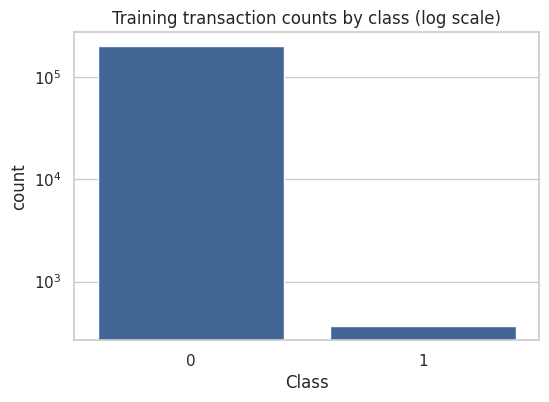

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda_df, x="Class", color="#3465a4", ax=ax)
ax.set_yscale("log")
ax.set_title("Training transaction counts by class (log scale)")
save_eda(fig, "chart_01_class_counts")

**Why this chart?** The logarithmic count axis makes the rare fraud class visible beside the normal class.

**Insight to read from it:** This quantifies the imbalance and explains why accuracy alone is misleading.

**Business impact and limitation:** Capacity planning should use expected alert counts rather than raw accuracy.

#### Chart - 2 - Raw amount distribution

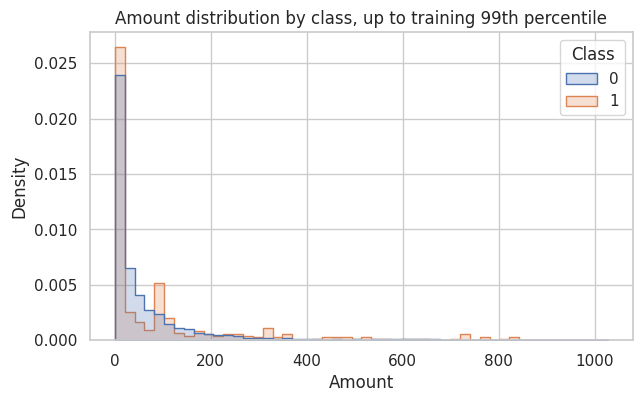

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
cap = eda_df["Amount"].quantile(0.99)
sns.histplot(data=eda_plot.loc[eda_plot["Amount"] <= cap], x="Amount", hue="Class", bins=50, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title("Amount distribution by class, up to training 99th percentile")
save_eda(fig, "chart_02_amount_hist")

**Why this chart?** The clipped histogram reveals the body of transaction values without allowing extreme amounts to hide it.

**Insight to read from it:** Compare the class distributions; amount alone may overlap substantially.

**Business impact and limitation:** A simple amount rule is explainable but can miss ordinary-value fraud and flag legitimate large purchases.

#### Chart - 3 - Log amount distribution

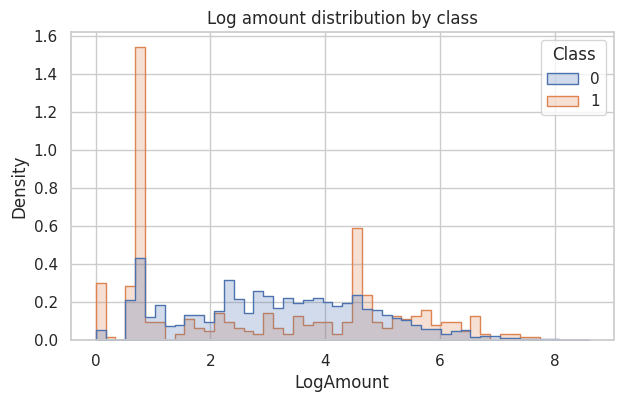

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=eda_plot, x="LogAmount", hue="Class", bins=50, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title("Log amount distribution by class")
save_eda(fig, "chart_03_log_amount_hist")

**Why this chart?** A log transform compresses the long right tail for a clearer comparison.

**Insight to read from it:** Assess whether the class curves separate more clearly after transformation; overlap remains possible.

**Business impact and limitation:** The transformed amount can help the model while avoiding domination by a few very large purchases.

#### Chart - 4 - Elapsed transaction time

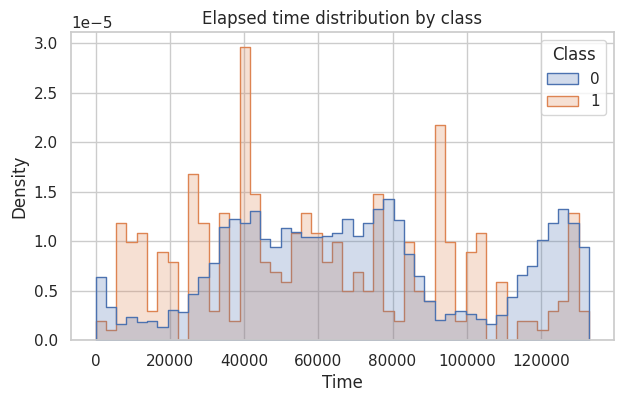

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=eda_plot, x="Time", hue="Class", bins=48, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title("Elapsed time distribution by class")
save_eda(fig, "chart_04_elapsed_time")

**Why this chart?** Time order is central to the validation design and potential activity patterns.

**Insight to read from it:** The curves show when each class occurs within the recorded two-day window.

**Business impact and limitation:** Operational volume can vary by time; thresholds and staffing would need monitoring across periods.

#### Chart - 5 - Fraud rate by hour

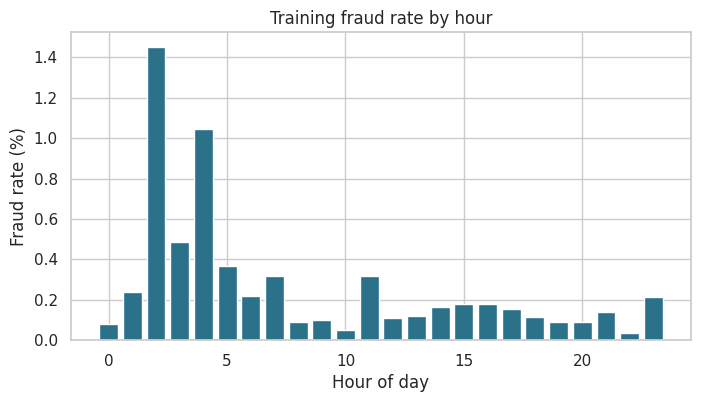

In [15]:
hourly = eda_df.assign(Hour=((eda_df["Time"] // 3600) % 24).astype(int)).groupby("Hour")["Class"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(hourly.index, 100 * hourly["mean"], color="#2a7189")
ax.set(xlabel="Hour of day", ylabel="Fraud rate (%)", title="Training fraud rate by hour")
save_eda(fig, "chart_05_hourly_fraud_rate")

**Why this chart?** Hourly rates show relative risk rather than just transaction volume.

**Insight to read from it:** Compare hourly proportions cautiously because some hours may have few frauds.

**Business impact and limitation:** This can guide review scheduling, but a two-day pattern is too short to become a fixed policy.

#### Chart - 6 - Amount spread by class

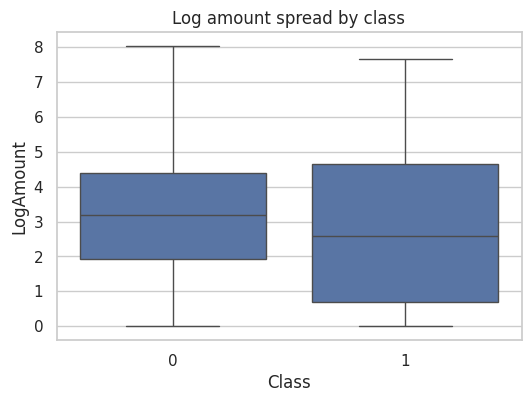

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=eda_plot, x="Class", y="LogAmount", showfliers=False, ax=ax)
ax.set_title("Log amount spread by class")
save_eda(fig, "chart_06_amount_box")

**Why this chart?** A box plot summarizes medians and dispersion without assuming a symmetric distribution.

**Insight to read from it:** Inspect the overlap and tails on the logarithmic scale; an amount threshold alone cannot define fraud.

**Business impact and limitation:** It highlights how a simplistic large-amount alert could increase customer friction.

#### Chart - 7 - Median transaction amount

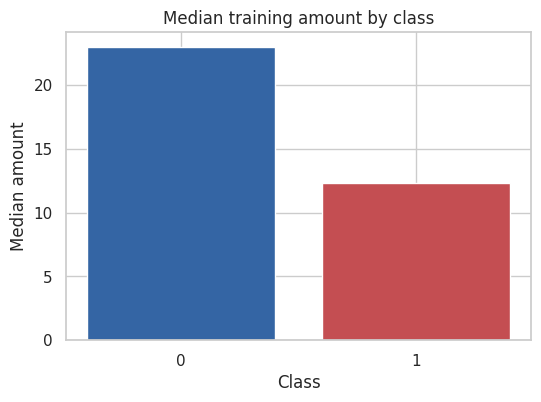

In [17]:
medians = eda_df.groupby("Class")["Amount"].median()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(medians.index.astype(str), medians.values, color=["#3465a4", "#c44e52"])
ax.set(xlabel="Class", ylabel="Median amount", title="Median training amount by class")
save_eda(fig, "chart_07_median_amount")

**Why this chart?** Medians resist the extreme-value influence visible in the raw distribution.

**Insight to read from it:** The bars show the central transaction value in each class, not a classification rule.

**Business impact and limitation:** Use this to explain typical transaction size while keeping alert decisions multivariate.

#### Chart - 8 - Time versus log amount

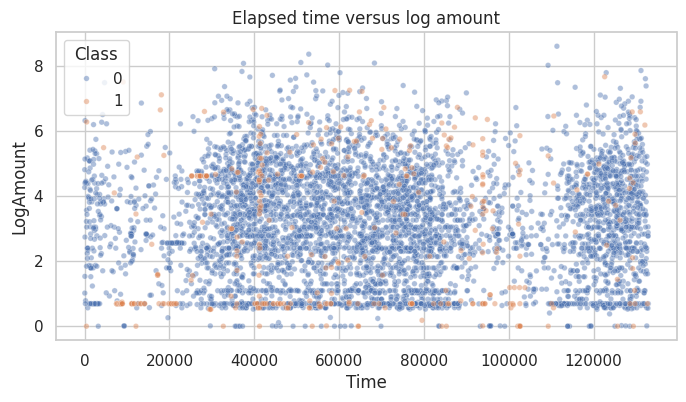

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(data=eda_plot, x="Time", y="LogAmount", hue="Class", alpha=0.45, s=16, ax=ax)
ax.set_title("Elapsed time versus log amount")
save_eda(fig, "chart_08_time_amount_scatter")

**Why this chart?** A scatter plot checks whether suspicious behaviour clusters jointly in time and transaction size.

**Insight to read from it:** Look for overlap and local concentrations rather than assuming linear separation.

**Business impact and limitation:** Joint patterns may be useful for triage but need stability checks beyond the two-day sample.

#### Chart - 9 - V14 distribution

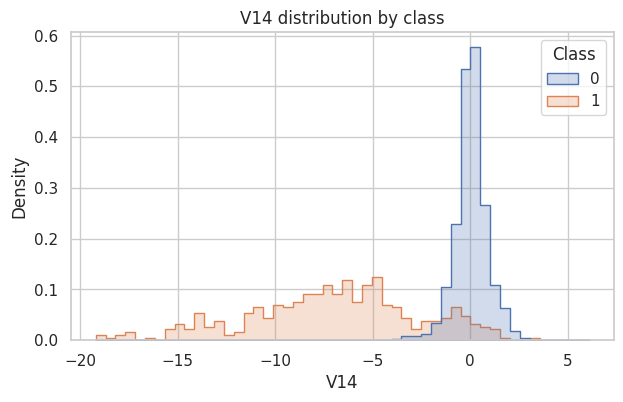

In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=eda_plot, x="V14", hue="Class", bins=50, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title("V14 distribution by class")
save_eda(fig, "chart_09_v14_hist")

**Why this chart?** An anonymized model feature can show class separation even though its business meaning is hidden.

**Insight to read from it:** Compare density overlap and tails without treating it as a causal driver.

**Business impact and limitation:** A useful signal can improve ranking, but anonymization limits investigator explanations.

#### Chart - 10 - V17 spread

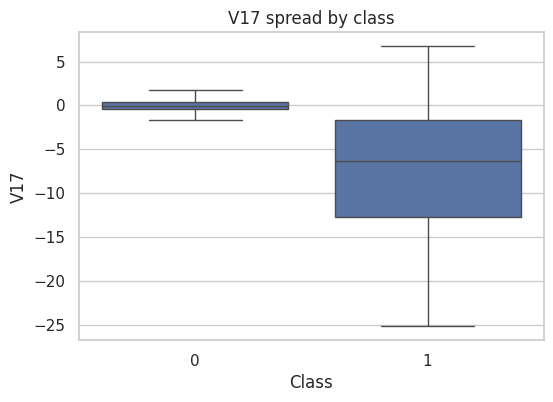

In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=eda_plot, x="Class", y="V17", showfliers=False, ax=ax)
ax.set_title("V17 spread by class")
save_eda(fig, "chart_10_v17_box")

**Why this chart?** The box plot exposes class differences and within-class variation in another anonymized feature.

**Insight to read from it:** A single feature may separate some cases yet still overlap across classes.

**Business impact and limitation:** Reviewers should rely on combined scores and threshold evidence, not an unexplained one-variable rule.

#### Chart - 11 - V12 distribution

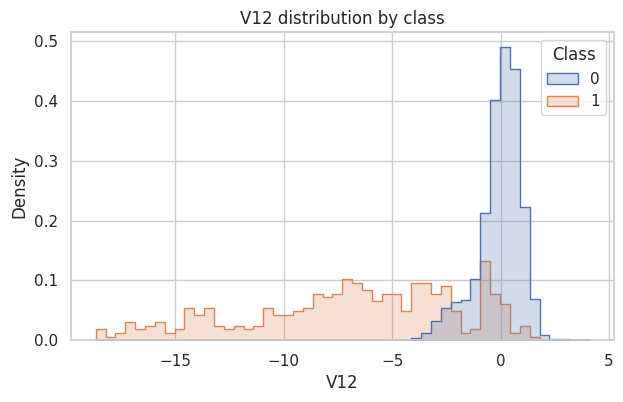

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=eda_plot, x="V12", hue="Class", bins=50, stat="density", common_norm=False, element="step", ax=ax)
ax.set_title("V12 distribution by class")
save_eda(fig, "chart_11_v12_hist")

**Why this chart?** A second anonymized feature checks whether visible separation is limited to V14.

**Insight to read from it:** Compare the class-density overlap and possible tails.

**Business impact and limitation:** Multiple weak signals can add value together, while unstable single-feature rules can cause false alerts.

#### Chart - 12 - V14 versus V17

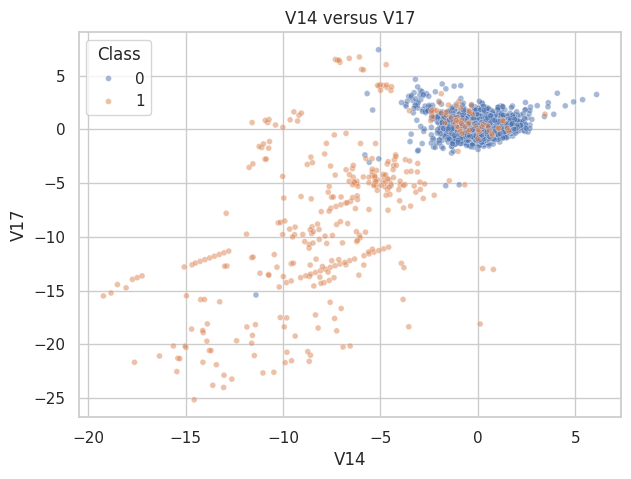

In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=eda_plot, x="V14", y="V17", hue="Class", alpha=0.5, s=18, ax=ax)
ax.set_title("V14 versus V17")
save_eda(fig, "chart_12_v14_v17_scatter")

**Why this chart?** Two-feature scatter helps reveal non-linear or overlapping fraud patterns.

**Insight to read from it:** Look for regions containing both classes as well as locally unusual frauds.

**Business impact and limitation:** Local structure motivates comparing LOF with global and reconstruction-based methods.

#### Chart - 13 - Fraud rate by amount decile

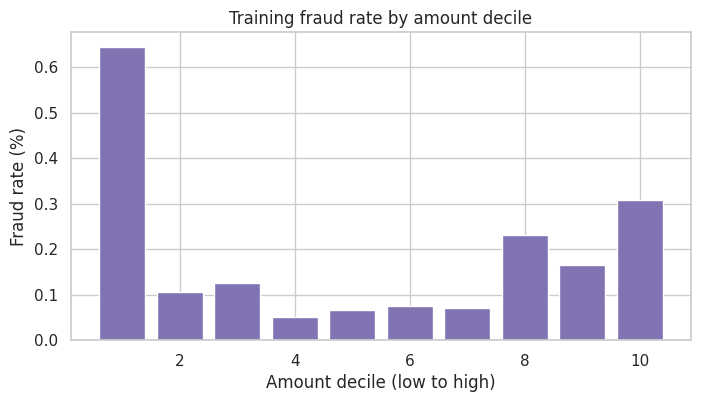

In [23]:
amount_band = pd.qcut(eda_df["Amount"].rank(method="first"), q=10, labels=False)
deciles = eda_df.groupby(amount_band)["Class"].agg(["mean", "count"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(deciles.index + 1, 100 * deciles["mean"], color="#8172b2")
ax.set(xlabel="Amount decile (low to high)", ylabel="Fraud rate (%)", title="Training fraud rate by amount decile")
save_eda(fig, "chart_13_amount_deciles")

**Why this chart?** Deciles compare relative fraud frequency across transaction sizes without choosing an arbitrary cut-off.

**Insight to read from it:** Inspect whether risk changes monotonically; small rates should be interpreted with their transaction counts.

**Business impact and limitation:** Amount can inform ranking, but a fixed amount rule may waste investigation capacity.

#### Chart - 14 - Correlation heatmap

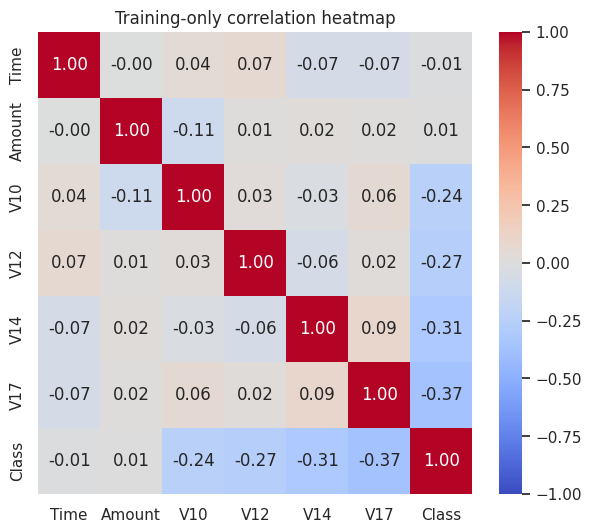

In [24]:
columns = ["Time", "Amount", "V10", "V12", "V14", "V17", "Class"]
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(eda_df[columns].corr(), cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f", ax=ax)
ax.set_title("Training-only correlation heatmap")
save_eda(fig, "chart_14_correlation_heatmap")

**Why this chart?** The template's heatmap gives a compact view of relationships among selected numeric columns.

**Insight to read from it:** Correlation with `Class` is descriptive; low linear correlation does not imply a feature is useless to non-linear models.

**Business impact and limitation:** It can flag redundant signals but should not select features from validation or test labels.

#### Chart - 15 - Pair plot

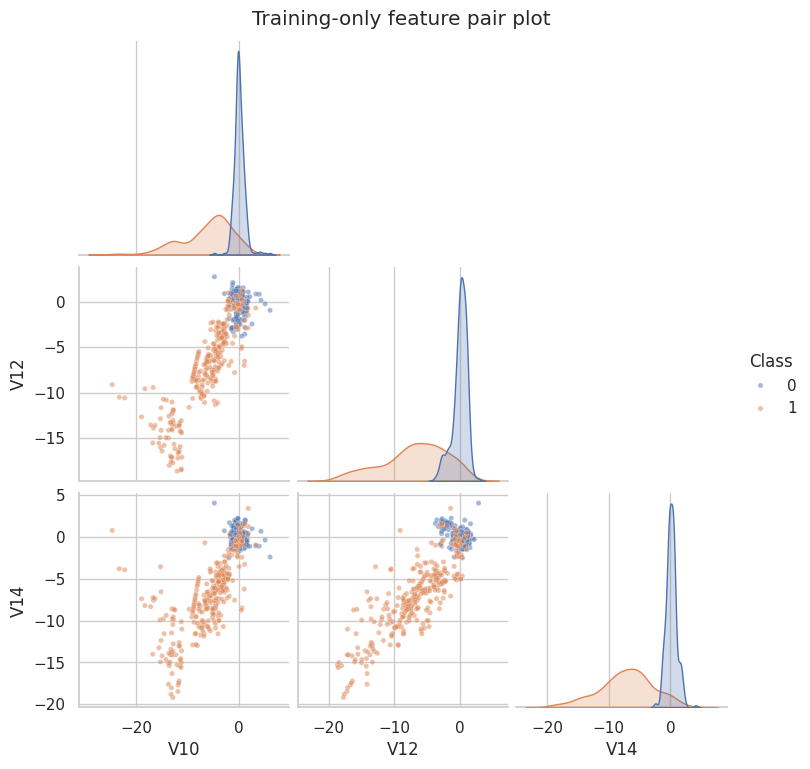

In [25]:
pair_normal = normal_plot.sample(n=min(300, len(normal_plot)), random_state=SEED)
pair_fraud = fraud_plot.sample(n=min(300, len(fraud_plot)), random_state=SEED)
pair_df = pd.concat([pair_normal, pair_fraud], ignore_index=True)
grid = sns.pairplot(pair_df, vars=["V10", "V12", "V14"], hue="Class", corner=True, plot_kws={"alpha": 0.5, "s": 14})
grid.figure.suptitle("Training-only feature pair plot", y=1.02)
save_eda(grid.figure, "chart_15_pair_plot")

**Why this chart?** The template's pair plot shows univariate distributions and pairwise geometry together.

**Insight to read from it:** Inspect overlap among `V10`, `V12`, and `V14`; the small sample is for visual legibility.

**Business impact and limitation:** These interactions motivate multivariate detectors but do not establish live generalization.

## ***5. Hypothesis Testing***

These three tests use **training data only** and are exploratory. They do not set features, thresholds, or model choice. With a large sample, a small effect can be statistically significant; report effect size and operational relevance alongside p-values. The alpha level is 0.05. No test below establishes causality.

### Hypothetical Statement - 1: Amount differs between classes

**H0:** The fraud and normal `LogAmount` distributions are the same. **H1:** They differ. A two-sided Mann–Whitney U test is appropriate for skewed, continuous values and does not assume normality. The normal class is deterministically sampled to 20,000 for computational economy; every training fraud is used.

In [26]:
from scipy.stats import mannwhitneyu, chi2_contingency

# Hypothesis tests use training labels only and do not select model settings.
normal_amount = eda_df.loc[eda_df["Class"] == 0, "LogAmount"].sample(
    n=min(20_000, int((eda_df["Class"] == 0).sum())), random_state=SEED
)
fraud_amount = eda_df.loc[eda_df["Class"] == 1, "LogAmount"]
amount_test = mannwhitneyu(fraud_amount, normal_amount, alternative="two-sided")
print(f"Mann–Whitney U={amount_test.statistic:,.0f}; p={amount_test.pvalue:.3g}; alpha=0.05")
print("Training medians:", eda_df.groupby("Class")["LogAmount"].median().to_dict())

Mann–Whitney U=3,308,750; p=0.00162; alpha=0.05
Training medians: {0: 3.1780538303479458, 1: 2.58851563240702}


### Hypothetical Statement - 2: Fraud frequency varies by time-of-day block

**H0:** The fraud proportion is independent of four six-hour blocks. **H1:** At least one block has a different proportion. Pearson's chi-square test is suitable for the 4×2 count table when expected counts are adequate; the code checks the minimum expected count. This two-day dataset cannot establish a stable seasonal pattern.

In [27]:
hour_block = (((eda_df["Time"] // 3600) % 24) // 6).astype(int)
hour_table = pd.crosstab(hour_block, eda_df["Class"])
chi2, hour_p, dof, expected = chi2_contingency(hour_table)
display(hour_table)
print(f"Chi-square={chi2:.3f}; p={hour_p:.3g}; dof={dof}; minimum expected count={expected.min():.2f}")

Class,0,1
Time,,
0,23727,115
1,70525,118
2,53733,78
3,50257,55


Chi-square=136.189; p=2.51e-29; dof=3; minimum expected count=43.94


### Hypothetical Statement - 3: An anonymized feature differs between classes

**H0:** The fraud and normal `V14` distributions are the same. **H1:** They differ. The two-sided Mann–Whitney U test tolerates non-normal values. `V14` has no disclosed business meaning, so even a statistically significant result is a descriptive association, not an explanation of fraud.

In [28]:
normal_v14 = eda_df.loc[eda_df["Class"] == 0, "V14"].sample(
    n=min(20_000, int((eda_df["Class"] == 0).sum())), random_state=SEED
)
fraud_v14 = eda_df.loc[eda_df["Class"] == 1, "V14"]
v14_test = mannwhitneyu(fraud_v14, normal_v14, alternative="two-sided")
print(f"Mann–Whitney U={v14_test.statistic:,.0f}; p={v14_test.pvalue:.3g}; alpha=0.05")
print("Training medians:", eda_df.groupby("Class")["V14"].median().to_dict())

Mann–Whitney U=371,950; p=2.95e-191; alpha=0.05
Training medians: {0: 0.07632669349724455, 1: -6.7649838810576455}


## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values
The audit above counts missing fields. Rows with unusable numeric predictors are removed by the cleaning helper; `Class` is never imputed. A production feed would need an approved missingness policy and training-fitted imputation if incomplete records were expected.

### 2. Handling Outliers
Extreme legitimate and fraudulent transactions remain in the dataset because removing them would erase the target phenomenon. `RobustScaler`, fitted on training only, reduces sensitivity to extremes for anomaly models. The IQR amount method is a baseline *detector*, not an outlier deletion step.

### 3. Categorical Encoding and Textual Data Preprocessing
The source has no categorical or text columns requiring encoding, tokenization, or NLP. `Class` is a label, not an input feature.

### 4. Feature Manipulation & Selection
`LogAmount`, `HourSin`, and `HourCos` supplement `V1`–`V28`. The input order is fixed by `MODEL_FEATURES`; the target and raw `Time`/`Amount` do not enter that matrix. Feature selection is not tuned on validation or test labels. The anonymized variables cannot be assigned business meanings.

### 5. Data Transformation and 6. Data Scaling
`log1p(Amount)` reduces right skew and the sine/cosine representation joins hour 23 smoothly to hour 0. The novelty detectors use a `RobustScaler` fit to training rows. The supervised Random Forest receives the unscaled engineered features, as trees do not need this scaling.

### 7. Dimensionality Reduction
PCA reconstruction is one candidate detector. It learns a normal-data subspace; mean squared reconstruction error is the score. There is **no downstream classifier after PCA**. Retained variance is tuned within the PCA family.

### 8. Data Splitting
The split created above is 70% training, 15% validation, and 15% test in time order when feasible. Training fits preprocessing and estimators; validation chooses hyperparameters and thresholds; test estimates locked performance once. A documented stratified fallback is used only when a small sample would omit a class.

### 9. Handling Imbalanced Dataset
Fraud is rare. PR-AUC, recall, F2, review workload, and relative cost are emphasized. Novelty detectors fit normal training records. SMOTE, if available, appears **inside the Random Forest training pipeline only** with a 5% minority sampling ratio and three neighbours; otherwise class-weighted Random Forest is fitted. Resampling is never applied to validation or test data.

## ***7. ML Model Implementation***

### ML Model - 1: Isolation Forest
Random partitions isolate unusual observations quickly. The search varies tree count and sample fraction. It is relatively practical for high-dimensional tabular data, but an unusual transaction is not necessarily fraudulent.

### ML Model - 2: Local Outlier Factor
LOF compares local density with neighbours. Novelty mode allows scoring later transactions; neighbourhood size is tuned. It can find local abnormalities but scoring and storage may be heavier.

### ML Model - 3: PCA Reconstruction
PCA learns a lower-dimensional normal-data subspace. Large mean squared reconstruction error indicates novelty. The search varies retained variance (`0.90`, `0.95`, `0.99` in the full run). The reconstruction score is thresholded directly; no classifier follows PCA.

### Additional controls: IQR amount baseline and supervised Random Forest
The IQR score is transparent but univariate. The Random Forest is a labelled benchmark with 400 trees, maximum depth 12, minimum leaf size 2, `balanced_subsample` weights, and seed 42 in the full run. Its parameters are fixed in this notebook; there is **no Random Forest hyperparameter grid search**.

### Cross-Validation & Hyperparameter Tuning
The anomaly-family grid is compared on a later chronological validation partition. Conventional random k-fold cross-validation would mix transaction times and weaken the future-scoring design. Each family chooses the setting with lowest validation relative cost; F2 and PR-AUC break ties. The final test is untouched during this choice.

In [29]:
# Tune each novelty-detector family against validation cost, never test cost.
anomaly_models, tuning_table = tune_anomaly_models(
    X_train_normal,
    X_validation,
    y_validation,
    false_negative_cost=FN_COST,
    false_positive_cost=FP_COST,
    fast_mode=FAST_MODE,
    random_state=SEED,
)
display(tuning_table.round(5))

validation_scores = {
    name: anomaly_score(name, model, X_validation)
    for name, model in anomaly_models.items()
}
test_scores = {
    name: anomaly_score(name, model, X_test)
    for name, model in anomaly_models.items()
}

validation_scores["IQR Amount Baseline"] = iqr_amount_score(
    split.validation, split.train
)
test_scores["IQR Amount Baseline"] = iqr_amount_score(split.test, split.train)

,Family,Parameters,Validation_Cost,F2,PR_AUC,Recall,Precision,Threshold,Selected
0,Isolation Forest,"{""max_samples"": 0.8, ""n_estimators"": 350}",773.0,0.37688,0.09543,0.54545,0.16854,0.52048,True
1,Isolation Forest,"{""max_samples"": 0.5, ""n_estimators"": 350}",808.0,0.30081,0.08339,0.67273,0.09367,0.47565,False
2,Isolation Forest,"{""max_samples"": ""auto"", ""n_estimators"": 350}",1227.0,0.17554,0.03097,0.52727,0.04785,0.57560,False
3,Isolation Forest,"{""max_samples"": ""auto"", ""n_estimators"": 200}",1233.0,0.17582,0.03235,0.58182,0.04638,0.56619,False
4,Local Outlier Factor,"{""n_neighbors"": 20}",471.0,0.49539,0.17935,0.78182,0.20093,2.09903,True
5,Local Outlier Factor,"{""n_neighbors"": 35}",499.0,0.52083,0.20815,0.72727,0.24390,2.30072,False
6,Local Outlier Factor,"{""n_neighbors"": 50}",506.0,0.47404,0.18720,0.76364,0.18834,2.18445,False
7,PCA Reconstruction,"{""variance_retained"": 0.99}",305.0,0.80224,0.78064,0.78182,0.89583,1.08487,True
8,PCA Reconstruction,"{""variance_retained"": 0.95}",343.0,0.70261,0.51739,0.78182,0.50000,1.21182,False
9,PCA Reconstruction,"{""variance_retained"": 0.9}",352.0,0.64516,0.50566,0.80000,0.36364,1.23093,False



### Supervised benchmark and the SMOTE neighbour change

The supervised pipeline applies SMOTE to the training partition and then fits the class-weighted Random Forest. We changed SMOTE `k_neighbors` from **5 to 3**. With rare frauds, three neighbours construct synthetic samples from a more local minority neighbourhood. That can preserve smaller fraud clusters and reduce interpolation across different fraud patterns. The drawback is greater sensitivity to individual noisy or mislabeled fraud points and potentially less diverse synthetic examples; five neighbours smooths more broadly but can bridge heterogeneous fraud clusters. Neither setting is universally better, and this is **a change to SMOTE's resampling geometry, not a tuned Random Forest parameter**.

In a separate same-environment local comparison recorded during project development, both settings caught 40 of 52 test frauds. With `k=3`, false alerts fell from 29 to 17, precision rose from 0.57971 to 0.70175, and F2 rose from 0.72202 to 0.75472; recall remained 0.76923. PR-AUC changed from 0.77550 to 0.77967, while ROC-AUC decreased from 0.97088 to 0.96742. The validation-selected thresholds differed (0.39638 for `k=5`, 0.45150 for `k=3`), so this comparison includes threshold re-selection.

**Note: These numbers belong to that local run on 283,726 cleaned rows with a 198,608/42,559/42,559 split and are not guaranteed Colab results. Live run numbers may vary.**

| SMOTE neighbours | TP | FN | FP | TN | Precision | Recall | F2 | PR-AUC | ROC-AUC |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 5 | 40 | 12 | 29 | 42,478 | 0.57971 | 0.76923 | 0.72202 | 0.77550 | 0.97088 |
| 3 | 40 | 12 | 17 | 42,490 | 0.70175 | 0.76923 | 0.75472 | 0.77967 | 0.96742 |

In [30]:
# Train RF on labelled training rows; SMOTE is confined to this fit pipeline.
supervised_model, imbalance_strategy = fit_supervised_benchmark(
    split.train[MODEL_FEATURES].to_numpy(dtype=float),
    y_train,
    random_state=SEED,
    fast_mode=FAST_MODE,
)
print("Supervised imbalance strategy:", imbalance_strategy)
validation_scores["Supervised RF Benchmark"] = supervised_model.predict_proba(
    split.validation[MODEL_FEATURES].to_numpy(dtype=float)
)[:, 1]
test_scores["Supervised RF Benchmark"] = supervised_model.predict_proba(
    split.test[MODEL_FEATURES].to_numpy(dtype=float)
)[:, 1]

Supervised imbalance strategy: SMOTE (training only) + class-weighted Random Forest


### Validation threshold optimization and evaluation metrics

An alert is issued when a suspicion score reaches its threshold. Validation chooses the threshold minimizing `25 × FN + 1 × FP`. The 25:1 ratio is an illustrative business assumption, not a measured bank cost. PR-AUC emphasizes ranking under imbalance; recall measures fraud capture; precision measures investigator yield; F2 emphasizes recall; false-positive rate and precision at 100 describe review burden. ROC-AUC is secondary because the overwhelming number of legitimate transactions can hide a costly alert workload.

In [31]:
threshold_choices = {}
validation_rows = []

# Lock one threshold per model using the validation partition.
for name, scores in validation_scores.items():
    choice = select_cost_threshold(
        y_validation,
        scores,
        false_negative_cost=FN_COST,
        false_positive_cost=FP_COST,
    )
    threshold_choices[name] = choice
    metrics = classification_metrics(y_validation, scores, choice["threshold"])
    metrics.update({
        "Model": name,
        "Validation_Cost": choice["validation_cost"],
        "Precision_at_100": precision_at_k(y_validation, scores, 100),
    })
    validation_rows.append(metrics)

validation_table = (
    pd.DataFrame(validation_rows)
    .set_index("Model")
    .sort_values(["F2", "PR_AUC"], ascending=False)
)
display(validation_table.round(5))

,PR_AUC,ROC_AUC,Precision,Recall,F1,F2,False_Positive_Rate,TN,FP,FN,TP,Threshold,Validation_Cost,Precision_at_100
Model,,,,,,,,,,,,,,
Supervised RF Benchmark,0.83491,0.98685,0.86538,0.81818,0.84112,0.82721,0.00016,42497,7,10,45,0.43574,257.0,0.45
PCA Reconstruction,0.78064,0.91647,0.89583,0.78182,0.83495,0.80224,0.00012,42499,5,12,43,1.08487,305.0,0.43
Local Outlier Factor,0.17935,0.95625,0.20093,0.78182,0.31970,0.49539,0.00402,42333,171,12,43,2.09903,471.0,0.27
Isolation Forest,0.09543,0.95948,0.16854,0.54545,0.25751,0.37688,0.00348,42356,148,25,30,0.52048,773.0,0.12
IQR Amount Baseline,0.00436,0.75137,0.00337,0.01818,0.00568,0.00967,0.00696,42208,296,54,1,1.64441,1646.0,0.00


Best overall model on validation F2: Supervised RF Benchmark
Best anomaly detector is selected separately below; RF is not in that restricted group.


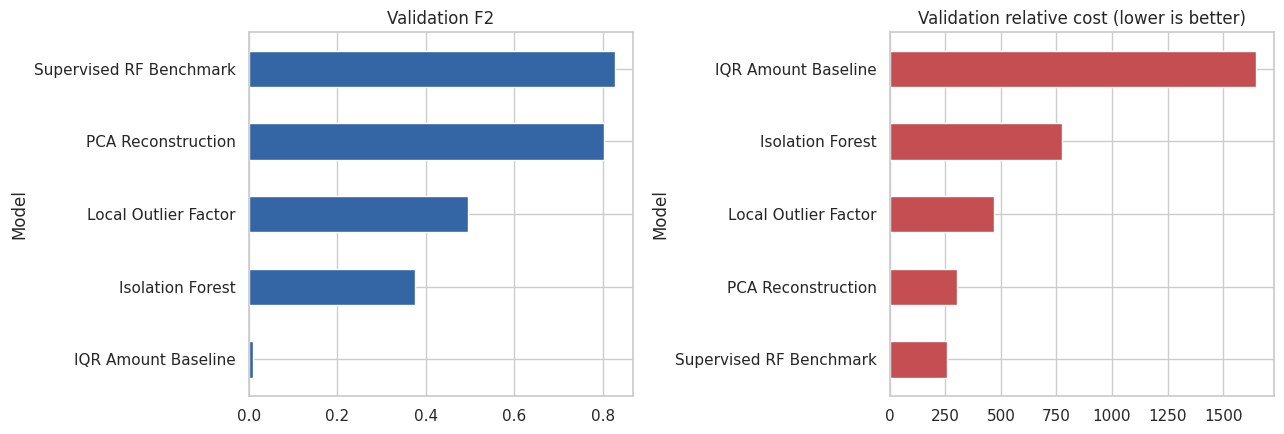

In [32]:
best_overall_name = validation_table["F2"].idxmax()
print("Best overall model on validation F2:", best_overall_name)
print("Best anomaly detector is selected separately below; RF is not in that restricted group.")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
validation_table["F2"].sort_values().plot.barh(ax=axes[0], color="#3465a4", title="Validation F2")
validation_table["Validation_Cost"].sort_values().plot.barh(ax=axes[1], color="#c44e52", title="Validation relative cost (lower is better)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_metric_score_chart.png", dpi=160, bbox_inches="tight")
plt.show()

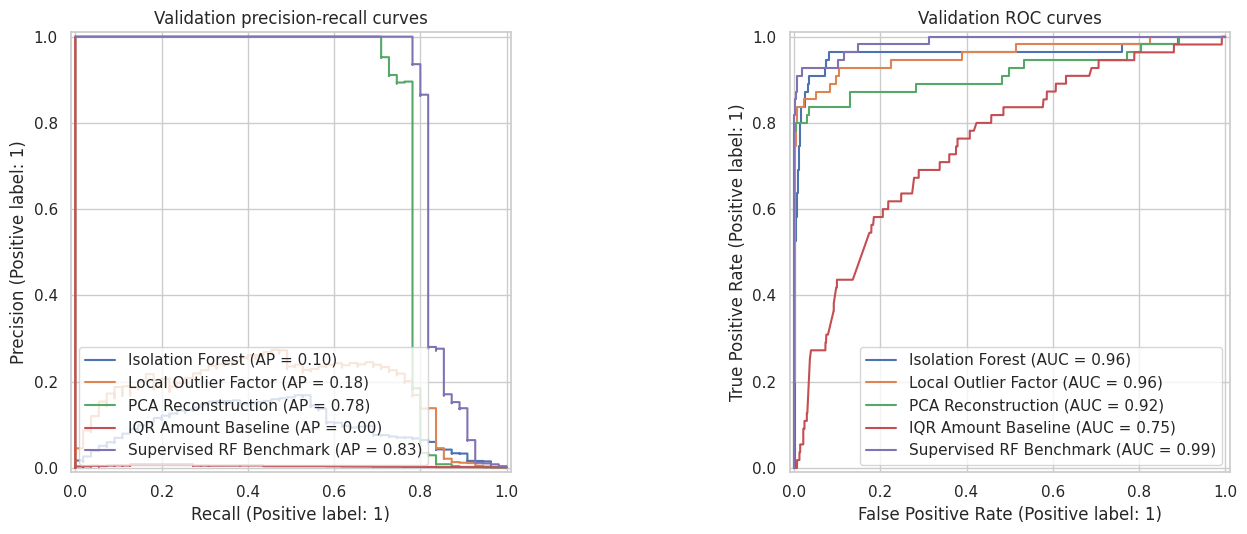

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name, scores in validation_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_validation, scores, name=name, ax=axes[0]
    )
    RocCurveDisplay.from_predictions(
        y_validation, scores, name=name, ax=axes[1]
    )
axes[0].set_title("Validation precision-recall curves")
axes[1].set_title("Validation ROC curves")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "validation_curves.png", dpi=160, bbox_inches="tight")
plt.show()

### Locked test evaluation and model comparison

The table below applies **validation-selected thresholds** to the untouched test partition. Its metrics are evidence for this run only if the source is real data. The test set must not be used to retune a model or threshold. The anomaly-only choice excludes the Random Forest by design; it does not imply the Random Forest performed worse overall. When labelled training data exist, a fitted Random Forest can score unlabelled incoming transactions with `predict_proba()`, but actual performance cannot be measured without later outcome labels.

In [34]:
test_rows = []
# Apply the locked thresholds once to the untouched test partition.
for name, scores in test_scores.items():
    threshold = threshold_choices[name]["threshold"]
    metrics = classification_metrics(y_test, scores, threshold)
    metrics.update({
        "Model": name,
        "Precision_at_100": precision_at_k(y_test, scores, 100),
        "Estimated_Business_Cost": FN_COST * metrics["FN"] + FP_COST * metrics["FP"],
    })
    test_rows.append(metrics)

test_table = (
    pd.DataFrame(test_rows)
    .set_index("Model")
    .sort_values(["F2", "PR_AUC"], ascending=False)
)
display(test_table.round(5))
test_table.to_csv(REPORTS_DIR / "model_comparison_test.csv")

,PR_AUC,ROC_AUC,Precision,Recall,F1,F2,False_Positive_Rate,TN,FP,FN,TP,Threshold,Precision_at_100,Estimated_Business_Cost
Model,,,,,,,,,,,,,,
Supervised RF Benchmark,0.78074,0.96628,0.70175,0.76923,0.73394,0.75472,0.00040,42490,17,12,40,0.43574,0.41,317.0
PCA Reconstruction,0.72539,0.89754,0.92500,0.71154,0.80435,0.74597,0.00007,42504,3,15,37,1.08487,0.39,378.0
Local Outlier Factor,0.24844,0.91718,0.22222,0.69231,0.33645,0.48649,0.00296,42381,126,16,36,2.09903,0.30,526.0
Isolation Forest,0.15569,0.94485,0.19084,0.48077,0.27322,0.36873,0.00249,42401,106,27,25,0.52048,0.23,781.0
IQR Amount Baseline,0.00352,0.70733,0.00565,0.01923,0.00873,0.01299,0.00414,42331,176,51,1,1.64441,0.00,1451.0


Best anomaly detector selected on validation F2: PCA Reconstruction
Best overall model selected on validation F2: Supervised RF Benchmark


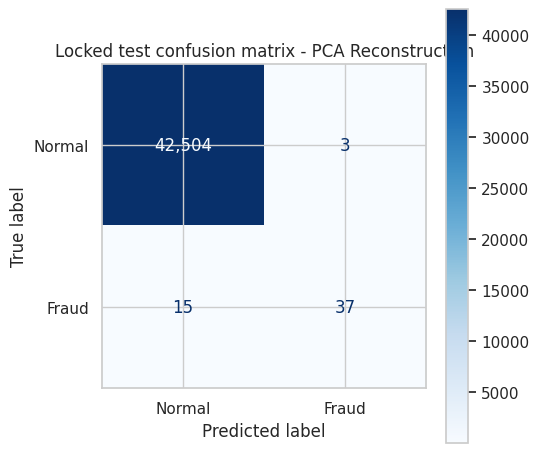

In [35]:
# This selection is anomaly-only; the supervised RF is compared separately.
anomaly_names = [*anomaly_models.keys(), "IQR Amount Baseline"]
best_anomaly_name = max(
    anomaly_names, key=lambda name: validation_table.loc[name, "F2"]
)
best_threshold = threshold_choices[best_anomaly_name]["threshold"]
best_predictions = (test_scores[best_anomaly_name] >= best_threshold).astype(int)
print("Best anomaly detector selected on validation F2:", best_anomaly_name)
print("Best overall model selected on validation F2:", best_overall_name)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_predictions, display_labels=["Normal", "Fraud"],
    cmap="Blues", values_format=",d", ax=ax,
)
ax.set_title(f"Locked test confusion matrix - {best_anomaly_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_anomaly_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

In [36]:
best_metrics = test_table.loc[best_anomaly_name]
operating_summary = {
    "selected_anomaly_model": best_anomaly_name,
    "test_transactions": int(len(y_test)),
    "alerts": int(best_metrics["TP"] + best_metrics["FP"]),
    "frauds_captured": int(best_metrics["TP"]),
    "frauds_missed": int(best_metrics["FN"]),
    "legitimate_reviews": int(best_metrics["FP"]),
    "recall": float(best_metrics["Recall"]),
    "precision": float(best_metrics["Precision"]),
    "f2": float(best_metrics["F2"]),
    "pr_auc": float(best_metrics["PR_AUC"]),
    "relative_cost": float(best_metrics["Estimated_Business_Cost"]),
}
display(operating_summary)
save_json(operating_summary, REPORTS_DIR / "operating_summary.json")

{'selected_anomaly_model': 'PCA Reconstruction',
 'test_transactions': 42559,
 'alerts': 40,
 'frauds_captured': 37,
 'frauds_missed': 15,
 'legitimate_reviews': 3,
 'recall': 0.7115384615384616,
 'precision': 0.925,
 'f2': 0.7459677419354839,
 'pr_auc': 0.7253892859231826,
 'relative_cost': 378.0}

PosixPath('/content/drive/MyDrive/Financial_Transaction_Anomaly_Detection/real_data/reports/operating_summary.json')

### Explainability and business interpretation

The Random Forest's impurity-based feature importance below is a model diagnostic, not a causal explanation. It can be biased toward some feature types and does not translate anonymized `V` columns into business concepts. For PCA, a high reconstruction error explains *why the score is high mathematically* but not the original economic cause. Decisions should therefore retain a reviewer and an audit trail.

,impurity_importance
V14,0.184464
V10,0.116851
V12,0.113203
V4,0.098355
V17,0.091298
V11,0.083778
V16,0.047179
V7,0.036049
V2,0.030811
V3,0.027799


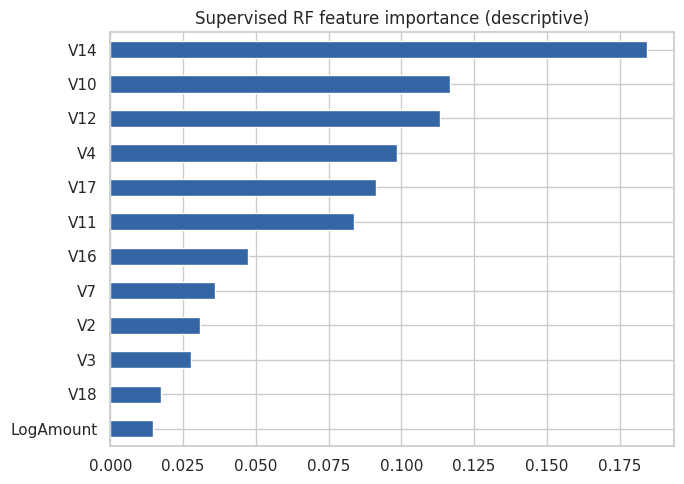

In [37]:
rf_estimator = (
    supervised_model.named_steps["random_forest"]
    if hasattr(supervised_model, "named_steps") else supervised_model
)
feature_importance = pd.Series(
    rf_estimator.feature_importances_, index=MODEL_FEATURES
).sort_values(ascending=False)
display(feature_importance.head(12).rename("impurity_importance").to_frame())
fig, ax = plt.subplots(figsize=(7, 5))
feature_importance.head(12).sort_values().plot.barh(ax=ax, color="#3465a4")
ax.set_title("Supervised RF feature importance (descriptive)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rf_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

## ***8. Future Work***

### 1. Save the chosen deployable model
The notebook saves the stronger of Isolation Forest and LOF by validation F2, including its fitted scaler, feature order, threshold, and run metadata. This deployable subset is distinct from the **best anomaly detector** and **best overall model** comparisons: PCA and Random Forest are evaluated but are not packaged by this code path. The saved bundle demonstrates notebook inference; it is not a live server.

In [38]:
# The saved scoring bundle currently supports these two novelty detectors.
deployment_candidates = ["Isolation Forest", "Local Outlier Factor"]
deployable_name = max(
    deployment_candidates,
    key=lambda name: validation_table.loc[name, "F2"],
)
deployable_threshold = threshold_choices[deployable_name]["threshold"]
bundle_path = save_detection_bundle(
    ARTIFACTS_DIR / "fraud_detection_bundle.joblib",
    model_name=deployable_name,
    model=anomaly_models[deployable_name],
    scaler=scaler,
    threshold=deployable_threshold,
    metadata={
        "dataset_source": source_info["source"],
        "is_synthetic": source_info["is_synthetic"],
        "split_strategy": split.strategy,
        "imbalance_strategy": imbalance_strategy,
        "false_negative_cost": FN_COST,
        "false_positive_cost": FP_COST,
        "validation_metrics": validation_table.loc[deployable_name].to_dict(),
        "test_metrics": test_table.loc[deployable_name].to_dict(),
    },
)
print("Saved deployment bundle:", bundle_path)
print("Model bundle saved in Google Drive.")

Saved deployment bundle: /content/drive/MyDrive/Financial_Transaction_Anomaly_Detection/real_data/artifacts/fraud_detection_bundle.joblib
Model bundle saved in Google Drive.


### 2. Reload the saved model and score a transaction
The next cell reloads the persisted bundle and applies its own stored feature order, scaler, model, and threshold to an example transaction with the target withheld. This is a serialization sanity check, not a held-out performance estimate.

In [39]:
import joblib

# Reload from disk to verify that stored model, scaler, and threshold work together.
loaded_bundle = joblib.load(bundle_path)
example_payload = split.test.iloc[0][loaded_bundle["raw_features"]]
example_frame = pd.DataFrame([example_payload.to_dict()])
example_features = engineer_features(example_frame)[loaded_bundle["model_features"]]
example_score = anomaly_score(
    loaded_bundle["model_name"], loaded_bundle["model"],
    loaded_bundle["scaler"].transform(example_features),
)[0]
display({
    "model": loaded_bundle["model_name"],
    "anomaly_score": float(example_score),
    "threshold": float(loaded_bundle["threshold"]),
    "decision": "manual_review" if example_score >= loaded_bundle["threshold"] else "allow",
})

{'model': 'Local Outlier Factor',
 'anomaly_score': 1.1492858858573878,
 'threshold': 2.099027159832221,
 'decision': 'allow'}

# **Conclusion**

This notebook follows the submission template while preserving a leakage-aware fraud-detection workflow. It documents data quality, 15 training-only charts, three exploratory hypotheses, feature engineering, class imbalance, three novelty detector families, a statistical baseline, and a supervised Random Forest benchmark. Validation data choose anomaly-family settings and alert thresholds; the test table evaluates locked decisions once. The 25:1 relative cost is illustrative, and review volume matters alongside recall and PR-AUC.

The anomaly-only selection and overall model comparison answer different questions. PCA reconstruction has no downstream classifier; Random Forest can score transactions without labels after labelled training, but the current saved inference bundle supports only Isolation Forest or LOF. The `k_neighbors=3` SMOTE setting reduced false alerts in one controlled local comparison, with the trade-off of greater sensitivity to local noise. The current Colab run's outputs should be used for the submission recommendation. Historical coverage, anonymized features, and missing entity context limit deployment claims. A live control requires human review, monitoring, calibrated costs, and later validation on current transactions.

## References

1. Machine Learning Group, Universite Libre de Bruxelles. *Credit Card Fraud Detection* dataset. Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
2. Scikit-learn documentation for Isolation Forest, Local Outlier Factor, PCA, Random Forest, and model-evaluation metrics: https://scikit-learn.org/stable/
3. imbalanced-learn documentation for SMOTE and leakage-safe pipelines: https://imbalanced-learn.org/stable/